splat area          0.8972
covered area        0.6960
coverage fraction   0.7757
wasted swath area   1.2338
efficiency          0.3607
greedy pass order   #2 (+0.3505), #1 (+0.2621), #0 (+0.0484), #3 (+0.0349)
monte carlo check   0.7735  (should match coverage fraction)
saved coverage.png


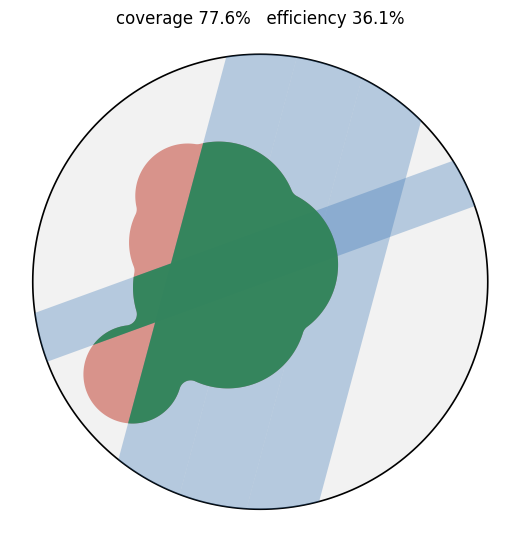

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import unary_union

QUAD = 64  # segments per quarter circle; higher = closer to a true circle


# ----------------------------------------------------------------------
# Geometry construction
# ----------------------------------------------------------------------

def make_map(radius=1.0):
    """The circular domain being mapped."""
    return Point(0.0, 0.0).buffer(radius, quad_segs=QUAD)


def make_splat(domain, rng, n_lobes=7, step=0.22, lobe_scale=0.28, smooth=0.05):
    """
    Random blob built as a union of overlapping disks placed by a random walk,
    then smoothed and clipped to the domain.

    smooth: closing radius. Dilating then eroding by the same amount rounds
            off the seams between lobes and kills thin slivers.
    """
    R = np.sqrt(domain.area / np.pi)
    center = np.array([0.0, 0.0])
    pos = center + rng.normal(scale=0.25 * R, size=2)

    lobes = []
    for _ in range(n_lobes):
        r = lobe_scale * R * rng.uniform(0.6, 1.4)
        lobes.append(Point(*pos).buffer(r, quad_segs=QUAD))
        pos = pos + rng.normal(scale=step * R, size=2)

    splat = unary_union(lobes)
    splat = splat.buffer(smooth * R, quad_segs=QUAD).buffer(-smooth * R, quad_segs=QUAD)
    splat = splat.intersection(domain)
    return splat.buffer(0)  # normalize any self-touching edges


def make_swath(theta, offset, width, domain):
    """
    One satellite pass over the disk, modeled as a straight ground track at
    angle theta whose perpendicular distance from the origin is offset.
    Returns the swath polygon clipped to the domain.
    """
    R = np.sqrt(domain.area / np.pi)
    d = np.array([np.cos(theta), np.sin(theta)])   # along-track
    n = np.array([-np.sin(theta), np.cos(theta)])  # cross-track
    p0 = offset * n - 2 * R * d
    p1 = offset * n + 2 * R * d
    track = LineString([p0, p1])
    return track.buffer(width / 2.0, cap_style=2).intersection(domain)


# ----------------------------------------------------------------------
# Coverage metrics (this is the part matplotlib could not give you)
# ----------------------------------------------------------------------

def coverage_report(splat, swaths, domain):
    """Exact areas, plus the greedy marginal gain of each pass."""
    union = unary_union(swaths) if swaths else Polygon()
    covered = union.intersection(splat)

    report = {
        "splat_area": splat.area,
        "domain_area": domain.area,
        "swath_area_on_map": union.area,
        "covered_area": covered.area,
        "coverage_fraction": covered.area / splat.area if splat.area else 0.0,
        "wasted_area": union.area - covered.area,
        "efficiency": covered.area / union.area if union.area else 0.0,
    }

    # Marginal contribution of each pass, in greedy order
    remaining = splat
    order = []
    pool = list(enumerate(swaths))
    while pool:
        best_i, best_geom, best_gain = None, None, -1.0
        for i, s in pool:
            gain = remaining.intersection(s).area
            if gain > best_gain:
                best_i, best_geom, best_gain = i, s, gain
        order.append((best_i, best_gain))
        remaining = remaining.difference(best_geom)
        pool = [(i, s) for i, s in pool if i != best_i]
    report["greedy_order"] = order
    report["uncovered_area"] = remaining.area
    return report




def monte_carlo_fraction(splat, swaths, rng, n=200_000):
    """Sampling-based estimate of covered_area / splat_area."""
    minx, miny, maxx, maxy = splat.bounds
    pts = rng.uniform([minx, miny], [maxx, maxy], size=(n, 2))
    union = unary_union(swaths)
    inside = 0
    hit = 0
    for x, y in pts:
        p = Point(x, y)
        if splat.contains(p):
            inside += 1
            if union.contains(p):
                hit += 1
    return hit / inside if inside else 0.0


# ----------------------------------------------------------------------
# Plotting
# ----------------------------------------------------------------------

def _patch(ax, geom, **kw):
    geoms = geom.geoms if geom.geom_type.startswith("Multi") else [geom]
    for g in geoms:
        if g.is_empty:
            continue
        ax.add_patch(MplPolygon(np.array(g.exterior.coords), **kw))
        for ring in g.interiors:
            ax.add_patch(MplPolygon(np.array(ring.coords), facecolor="white", edgecolor="none"))


def plot_scene(domain, splat, swaths, report, path="coverage.png"):
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    _patch(ax, domain, facecolor="#f2f2f2", edgecolor="black", linewidth=1.2)
    _patch(ax, splat, facecolor="#c44536", edgecolor="none", alpha=0.55)
    for s in swaths:
        _patch(ax, s, facecolor="#2b6cb0", edgecolor="none", alpha=0.30)
    covered = unary_union(swaths).intersection(splat)
    _patch(ax, covered, facecolor="#2f855a", edgecolor="none", alpha=0.95)

    R = np.sqrt(domain.area / np.pi)
    ax.set_xlim(-1.1 * R, 1.1 * R)
    ax.set_ylim(-1.1 * R, 1.1 * R)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(
        f"coverage {report['coverage_fraction']:.1%}   "
        f"efficiency {report['efficiency']:.1%}"
    )
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path


# ----------------------------------------------------------------------

if __name__ == "__main__":
    rng = np.random.default_rng(7)

    domain = make_map(1.0)
    splat = make_splat(domain, rng)

    swaths = [
        make_swath(theta=np.deg2rad(75), offset=-0.35, width=0.30, domain=domain),
        make_swath(theta=np.deg2rad(75), offset=-0.05, width=0.30, domain=domain),
        make_swath(theta=np.deg2rad(75), offset=+0.25, width=0.30, domain=domain),
        make_swath(theta=np.deg2rad(20), offset=+0.10, width=0.22, domain=domain),
    ]

    rep = coverage_report(splat, swaths, domain)
    print(f"splat area          {rep['splat_area']:.4f}")
    print(f"covered area        {rep['covered_area']:.4f}")
    print(f"coverage fraction   {rep['coverage_fraction']:.4f}")
    print(f"wasted swath area   {rep['wasted_area']:.4f}")
    print(f"efficiency          {rep['efficiency']:.4f}")
    print("greedy pass order   " + ", ".join(f"#{i} (+{g:.4f})" for i, g in rep["greedy_order"]))

    mc = monte_carlo_fraction(splat, swaths, rng, n=40_000)
    print(f"monte carlo check   {mc:.4f}  (should match coverage fraction)")

    print("saved", plot_scene(domain, splat, swaths, rep))

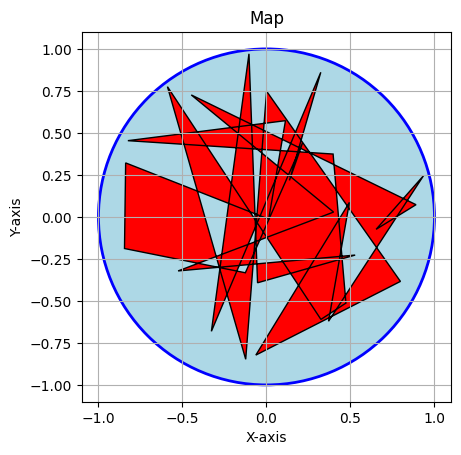

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import numpy as np

# Create a figure and an axes
fig, ax = plt.subplots(1)

# Create a circle patch
circle = patches.Circle((0, 0), radius=1.0, fc='lightblue', ec='blue', linewidth=2)
ax.add_patch(circle)

# circle
ax.set_aspect('equal', adjustable='box')

# Plot scale
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])

# Path
points = []
for i in range(30):
  candidate = (np.random.uniform(-1, 1), np.random.uniform(-1, 1))
  while candidate[0]**2 + candidate[1]**2 >= 1:
    candidate = (np.random.uniform(-1, 1), np.random.uniform(-1, 1))
  points.append(candidate)

#Patch from path
patchPath = path.Path(points, closed = True).cleaned(curves=True)
splat = patches.PathPatch(path=patchPath, facecolor='red')
ax.add_patch(splat)

ax.set_title('Map')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')

plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import numpy as np




ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (2,)

saved perlin_splats.png


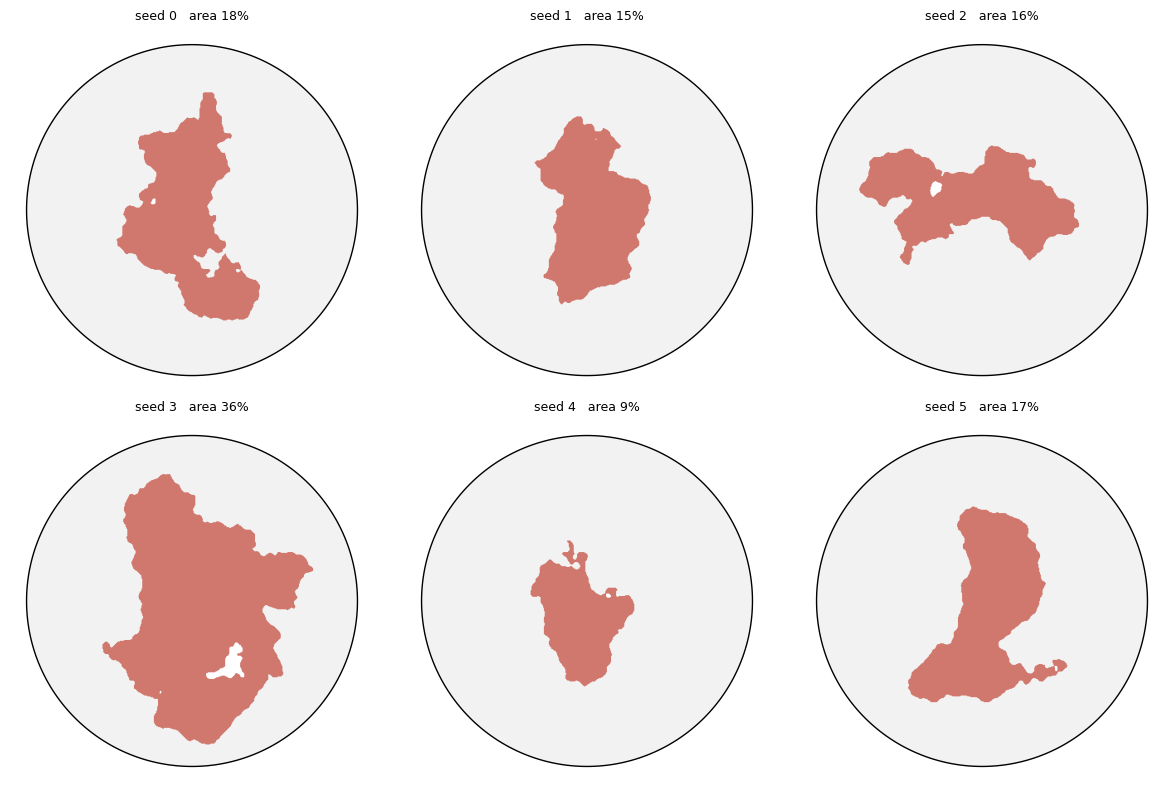

In [6]:

import numpy as np
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from skimage import measure

QUAD = 64


def _perlin_grid(res, rng):
    ry, rx = res
    H, W = _perlin_grid.shape

    # corner gradients
    ang = 2 * np.pi * rng.random((ry + 1, rx + 1))
    grad = np.dstack((np.cos(ang), np.sin(ang)))

    # sample coords
    ys = np.linspace(0, ry, H, endpoint=False)
    xs = np.linspace(0, rx, W, endpoint=False)
    gy, gx = np.meshgrid(ys, xs, indexing="ij")

    y0 = gy.astype(int); x0 = gx.astype(int)
    fy = gy - y0;        fx = gx - x0

    def dot(iy, ix, oy, ox):
        g = grad[(y0 + iy), (x0 + ix)]
        return g[..., 0] * (fy - oy) + g[..., 1] * (fx - ox)

    n00 = dot(0, 0, 0, 0)
    n01 = dot(0, 1, 0, 1)
    n10 = dot(1, 0, 1, 0)
    n11 = dot(1, 1, 1, 1)

    def fade(t):
        return 6 * t**5 - 15 * t**4 + 10 * t**3

    u = fade(fx); v = fade(fy)
    top = n00 * (1 - u) + n01 * u
    bot = n10 * (1 - u) + n11 * u
    return top * (1 - v) + bot * v


def fractal_noise(shape, rng, octaves=5, base_res=3, persistence=0.5, lacunarity=2):

    _perlin_grid.shape = shape
    field = np.zeros(shape)
    amp = 1.0
    freq = base_res
    norm = 0.0
    for _ in range(octaves):
        field += amp * _perlin_grid((freq, freq), rng)
        norm += amp
        amp *= persistence
        freq = int(freq * lacunarity)
    return field / norm

def _mask_to_polygons(field, level, extent):

    H, W = field.shape
    minx, maxx, miny, maxy = extent
    mask = np.pad((field > level).astype(float), 1, constant_values=0.0)

    loops = []
    for c in measure.find_contours(mask, 0.5):

        rr = c[:, 0] - 1
        cc = c[:, 1] - 1
        x = minx + (cc / (W - 1)) * (maxx - minx)
        y = miny + (rr / (H - 1)) * (maxy - miny)
        ring = Polygon(np.column_stack([x, y]))
        if ring.is_valid and ring.area > 0:
            loops.append(ring)

    if not loops:
        return Polygon()
    reps = [lp.representative_point() for lp in loops]
    depth = [sum(other.contains(reps[i]) for k, other in enumerate(loops) if k != i)
             for i in range(len(loops))]
    shells = [i for i in range(len(loops)) if depth[i] % 2 == 0]
    holes = [i for i in range(len(loops)) if depth[i] % 2 == 1]

    polys = []
    for i in shells:
        my_holes = []
        for h in holes:
            if not loops[i].contains(reps[h]):
                continue
            parent = min(
                (s for s in shells if loops[s].contains(reps[h])),
                key=lambda s: loops[s].area,
            )
            if parent == i:
                my_holes.append(np.array(loops[h].exterior.coords))
        polys.append(Polygon(np.array(loops[i].exterior.coords), my_holes))

    return unary_union([p.buffer(0) for p in polys])


def make_perlin_splat(domain,rng,grid=400,
    octaves=5, #lower smoother
    base_res=3,
    persistence=0.5, #lower smoother
    threshold=0.8, # size - higher shirnks
    falloff=1.6,
    min_area_frac=0.01,
):

    R = np.sqrt(domain.area / np.pi)
    field = fractal_noise((grid, grid), rng, octaves=octaves,
                          base_res=base_res, persistence=persistence)

    # normalize to [0, 1]
    field = (field - field.min()) / (np.ptp(field) + 1e-12)

    # subtract a bowl that rises toward the edge
    if falloff > 0:
        lin = np.linspace(-1, 1, grid)
        xx, yy = np.meshgrid(lin, lin)
        rr = np.sqrt(xx**2 + yy**2)
        field = field - (rr ** falloff)
        field = (field - field.min()) / (np.ptp(field) + 1e-12)

    extent = (-R, R, -R, R)
    splat = _mask_to_polygons(field, threshold, extent)
    splat = splat.intersection(domain).buffer(0)

    # keep only good blobs
    if isinstance(splat, MultiPolygon):
        keep = [g for g in splat.geoms if g.area >= min_area_frac * domain.area]
        splat = unary_union(keep) if keep else max(splat.geoms, key=lambda g: g.area)

    return splat




if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.patches import Polygon as MplPolygon
    from shapely.geometry import Point

    def patch(ax, geom, **kw):
        geoms = geom.geoms if geom.geom_type.startswith("Multi") else [geom]
        for g in geoms:
            if g.is_empty:
                continue
            ax.add_patch(MplPolygon(np.array(g.exterior.coords), **kw))
            for ring in g.interiors:
                ax.add_patch(MplPolygon(np.array(ring.coords), facecolor="white", edgecolor="none"))

    domain = Point(0, 0).buffer(1.0, quad_segs=QUAD)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, seed in zip(axes.ravel(), range(6)):
        rng = np.random.default_rng(seed)
        splat = make_perlin_splat(domain, rng)
        patch(ax, domain, facecolor="#f2f2f2", edgecolor="black", linewidth=1.0)
        patch(ax, splat, facecolor="#c44536", edgecolor="none", alpha=0.7)
        ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_title(f"seed {seed}   area {splat.area/domain.area:.0%}", fontsize=9)

    fig.tight_layout()
    fig.savefig("perlin_splats.png", dpi=130, bbox_inches="tight")
    print("saved perlin_splats.png")